# Exploración vs Explotación

La principal diferencia entre el axr y el resto de métodos de aprendizaje es que durante el entrenamiento un agente aprende a través de la *evaluación* de las acciones tomadas en vez de ser *instruido* diciéndole exactamente qué acciones son las correctas (aprendizaje supervisado). Es por este motivo que necesitamos de una exploración activa, de forma que a través de la prueba y el error nuestro agente descubra las mejores acciones para poder explotarlas en el futuro.


# Pac-Man con Entorno de Simulación

Vamos a aplicar los métodos de bandits pero usando un entorno de simulación más realista.

## El Entorno

Creamos una clase `LaberintoEnv` que simula el laberinto de Pac-Man. El entorno es dinámico: las zonas visitadas reducen su densidad de pastillas y se regeneran con el tiempo.

Cada zona tiene:
- Un valor base de recompensa (desconocido para el agente)
- Un nivel de peligrosidad que afecta la varianza
- Una densidad de pastillas que cambia dinámicamente

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [30]:
class LaberintoEnv:
    def __init__(self, seed=42):
        self.zonas = ['Norte', 'Sur', 'Este', 'Oeste', 'Centro']
        self.n_zonas = len(self.zonas)
        self.rng = np.random.RandomState(seed)
        
        # Valores base de cada zona (desconocidos para el agente)
        self.q_base = {
            'Norte': 2.5,
            'Sur': 1.8,
            'Este': 3.2,
            'Oeste': 1.5,
            'Centro': 2.0
        }
        
        # Peligrosidad de cada zona (afecta varianza)
        self.peligro = {
            'Norte': 0.5,
            'Sur': 0.8,
            'Este': 0.3,
            'Oeste': 1.0,
            'Centro': 0.6
        }
        
        # Estado del entorno (densidad de pastillas)
        self.densidad = {z: 1.0 for z in self.zonas}
        
    def step(self, accion):
        """Ejecuta una acción y devuelve la recompensa"""
        # Convertir índice a nombre de zona
        zona = self.zonas[accion]
        
        # Recompensa base ajustada por densidad actual
        mu = self.q_base[zona] * self.densidad[zona]
        sigma = self.peligro[zona]
        
        # Muestra con ruido
        recompensa = self.rng.normal(mu, sigma)
        
        # Actualizar densidad (se reduce en la zona visitada)
        self.densidad[zona] = max(0.5, self.densidad[zona] - 0.05)
        
        # Regenerar en otras zonas
        for z in self.zonas:
            if z != zona:
                self.densidad[z] = min(1.0, self.densidad[z] + 0.01)
        
        return recompensa
    
    def reset(self):
        """Reinicia el entorno"""
        self.densidad = {z: 1.0 for z in self.zonas}
    
    def get_mejor_zona(self):
        """Devuelve el índice de la mejor zona (para medir optimalidad)"""
        mejor_nombre = max(self.q_base, key=self.q_base.get)
        return self.zonas.index(mejor_nombre)

## Método ε-Greedy en el Laberinto

In [31]:
# Valores epsilon a probar
epsilons = [0, 0.01, 0.1]
recompensas = {eps: [] for eps in epsilons}
acciones_optimas = {eps: [] for eps in epsilons}

for epsilon in epsilons:
    env = LaberintoEnv()
    k = len(env.zonas)
    Q = np.zeros(k)
    N = np.zeros(k)
    
    recompensas_totales = []
    selecciones_optimas = []
    
    for paso in range(500):
        # Estrategia ε-greedy
        if np.random.random() < epsilon:
            accion = np.random.randint(k)
        else:
            accion = np.argmax(Q)
        
        # Interactuar con el entorno
        recompensa = env.step(accion)
        
        # Actualizar estimaciones
        N[accion] += 1
        Q[accion] += (recompensa - Q[accion]) / N[accion]
        
        # Guardar métricas
        recompensas_totales.append(recompensa)
        mejor_zona = env.get_mejor_zona()
        selecciones_optimas.append(1 if accion == mejor_zona else 0)
    
    recompensas[epsilon] = recompensas_totales
    acciones_optimas[epsilon] = selecciones_optimas

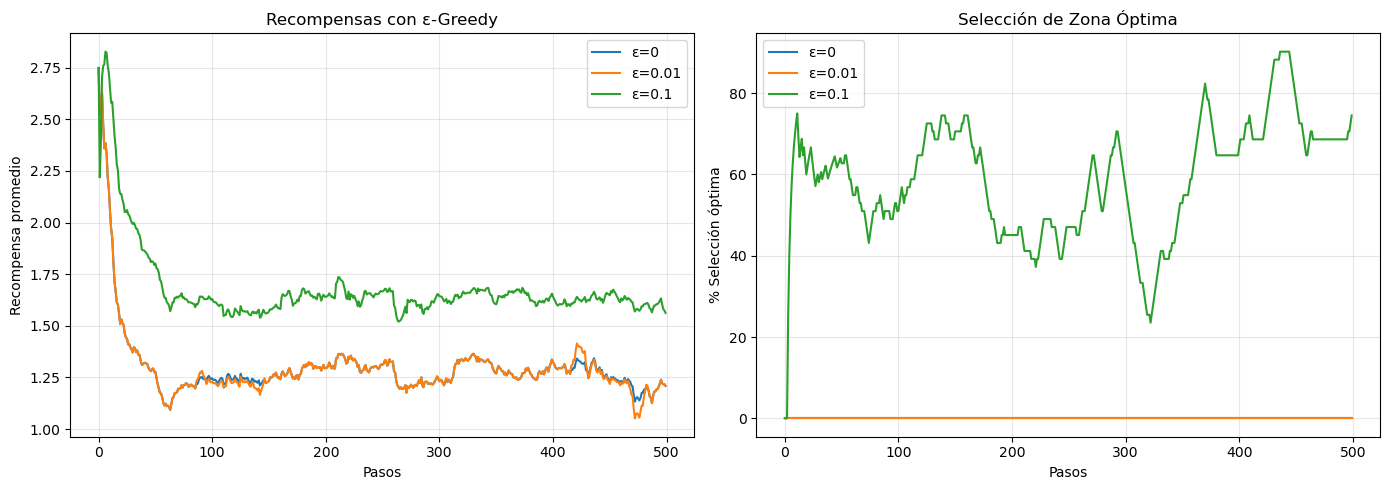

In [32]:
# Visualizar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for epsilon in epsilons:
    promedio_movil = [np.mean(recompensas[epsilon][max(0, i-50):i+1]) for i in range(len(recompensas[epsilon]))]
    ax1.plot(promedio_movil, label=f'ε={epsilon}')

ax1.set_xlabel('Pasos')
ax1.set_ylabel('Recompensa promedio')
ax1.set_title('Recompensas con ε-Greedy')
ax1.legend()
ax1.grid(True, alpha=0.3)

for epsilon in epsilons:
    promedio_optimas = [np.mean(acciones_optimas[epsilon][max(0, i-50):i+1]) * 100 for i in range(len(acciones_optimas[epsilon]))]
    ax2.plot(promedio_optimas, label=f'ε={epsilon}')

ax2.set_xlabel('Pasos')
ax2.set_ylabel('% Selección óptima')
ax2.set_title('Selección de Zona Óptima')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Con ε=0 (totalmente codicioso) el agente queda atrapado en zonas subóptimas. Con ε pequeño (0.01, 0.1) balancea exploración y explotación adaptándose a los cambios de densidad del laberinto.

## Método de Actualización Incremental

In [33]:
# Comparar actualización estándar vs incremental con α fijo
alphas = [0.1, 0.5, 1.0]
recompensas_alpha = {a: [] for a in alphas}
acciones_optimas_alpha = {a: [] for a in alphas}

for alpha in alphas:
    env = LaberintoEnv()
    k = len(env.zonas)
    Q = np.zeros(k)
    
    recompensas_totales = []
    selecciones_optimas = []
    
    for paso in range(500):
        # Estrategia ε-greedy con ε=0.1
        if np.random.random() < 0.1:
            accion = np.random.randint(k)
        else:
            accion = np.argmax(Q)
        
        recompensa = env.step(accion)
        
        # Actualización incremental con α fijo
        Q[accion] += alpha * (recompensa - Q[accion])
        
        recompensas_totales.append(recompensa)
        mejor_zona = env.get_mejor_zona()
        selecciones_optimas.append(1 if accion == mejor_zona else 0)
    
    recompensas_alpha[alpha] = recompensas_totales
    acciones_optimas_alpha[alpha] = selecciones_optimas

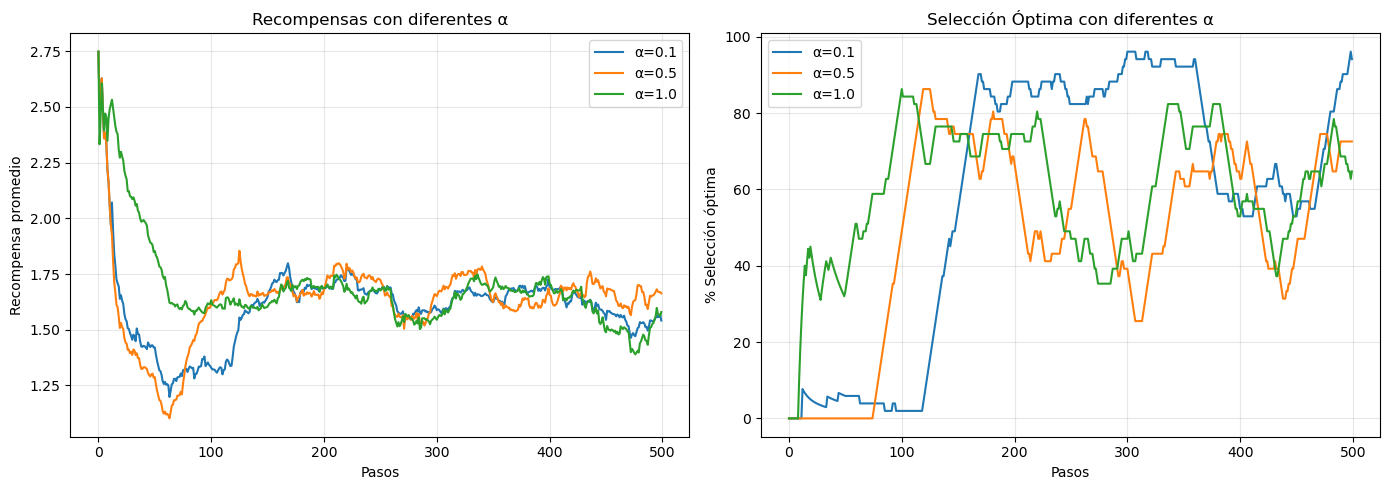

In [34]:
# Visualizar impacto de α
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for alpha in alphas:
    promedio_movil = [np.mean(recompensas_alpha[alpha][max(0, i-50):i+1]) for i in range(len(recompensas_alpha[alpha]))]
    ax1.plot(promedio_movil, label=f'α={alpha}')

ax1.set_xlabel('Pasos')
ax1.set_ylabel('Recompensa promedio')
ax1.set_title('Recompensas con diferentes α')
ax1.legend()
ax1.grid(True, alpha=0.3)

for alpha in alphas:
    promedio_optimas = [np.mean(acciones_optimas_alpha[alpha][max(0, i-50):i+1]) * 100 for i in range(len(acciones_optimas_alpha[alpha]))]
    ax2.plot(promedio_optimas, label=f'α={alpha}')

ax2.set_xlabel('Pasos')
ax2.set_ylabel('% Selección óptima')
ax2.set_title('Selección Óptima con diferentes α')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

α alto (0.5, 1.0) se adapta rápido a cambios en densidad pero es inestable. α bajo (0.1) es más estable pero reacciona lento cuando el laberinto cambia.

## Método con Valores Iniciales Optimistas

In [35]:
# Probar diferentes valores iniciales
valores_iniciales = [0, 5, 10]
recompensas_opt = {v: [] for v in valores_iniciales}
acciones_optimas_opt = {v: [] for v in valores_iniciales}

for valor_inicial in valores_iniciales:
    env = LaberintoEnv()
    k = len(env.zonas)
    Q = np.full(k, valor_inicial, dtype=float)
    
    recompensas_totales = []
    selecciones_optimas = []
    
    for paso in range(500):
        # Estrategia codiciosa (sin ε)
        accion = np.argmax(Q)
        
        recompensa = env.step(accion)
        
        # Actualización con α=0.1
        Q[accion] += 0.1 * (recompensa - Q[accion])
        
        recompensas_totales.append(recompensa)
        mejor_zona = env.get_mejor_zona()
        selecciones_optimas.append(1 if accion == mejor_zona else 0)
    
    recompensas_opt[valor_inicial] = recompensas_totales
    acciones_optimas_opt[valor_inicial] = selecciones_optimas

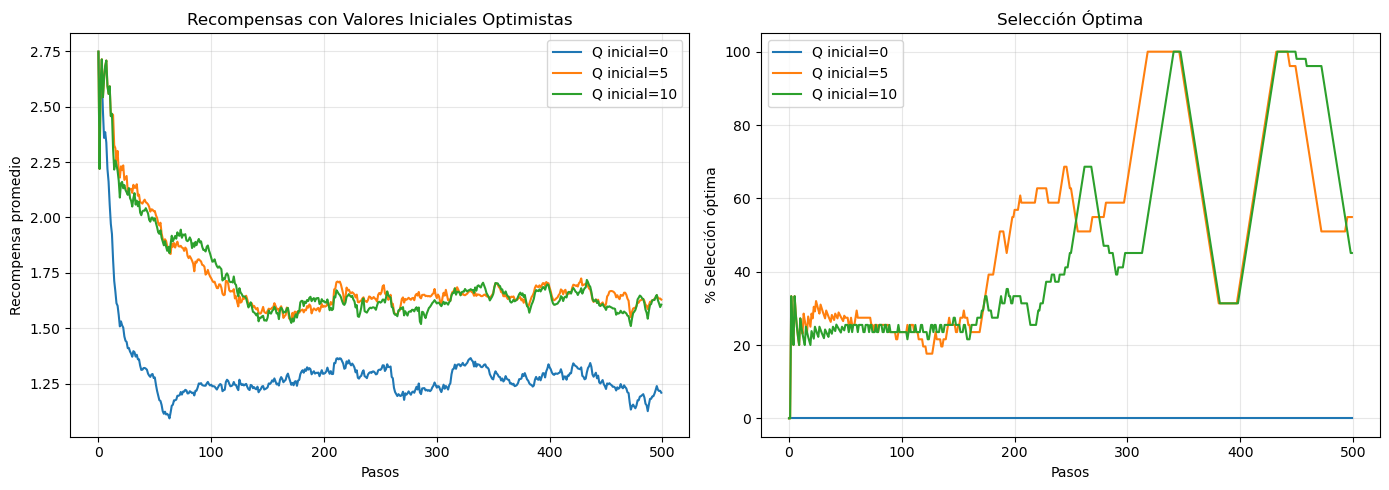

In [36]:
# Visualizar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for valor_inicial in valores_iniciales:
    promedio_movil = [np.mean(recompensas_opt[valor_inicial][max(0, i-50):i+1]) for i in range(len(recompensas_opt[valor_inicial]))]
    ax1.plot(promedio_movil, label=f'Q inicial={valor_inicial}')

ax1.set_xlabel('Pasos')
ax1.set_ylabel('Recompensa promedio')
ax1.set_title('Recompensas con Valores Iniciales Optimistas')
ax1.legend()
ax1.grid(True, alpha=0.3)

for valor_inicial in valores_iniciales:
    promedio_optimas = [np.mean(acciones_optimas_opt[valor_inicial][max(0, i-50):i+1]) * 100 for i in range(len(acciones_optimas_opt[valor_inicial]))]
    ax2.plot(promedio_optimas, label=f'Q inicial={valor_inicial}')

ax2.set_xlabel('Pasos')
ax2.set_ylabel('% Selección óptima')
ax2.set_title('Selección Óptima')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Los valores iniciales altos fuerzan exploración temprana. Q=10 hace que el agente pruebe todas las zonas al inicio antes de comprometerse.

## Método UCB (Upper Confidence Bound)

In [37]:
# Valores de c a probar
valores_c = [0.5, 1, 2]
recompensas_ucb = {c: [] for c in valores_c}
acciones_optimas_ucb = {c: [] for c in valores_c}

for c in valores_c:
    env = LaberintoEnv()
    k = len(env.zonas)
    Q = np.zeros(k)
    N = np.zeros(k)
    
    recompensas_totales = []
    selecciones_optimas = []
    
    for paso in range(500):
        # Calcular UCB para cada acción
        if paso < k:
            accion = paso  # Explorar cada zona al menos una vez
        else:
            bonus = c * np.sqrt(np.log(paso + 1) / (N + 1e-10))
            ucb = Q + bonus
            accion = np.argmax(ucb)
        
        recompensa = env.step(accion)
        
        N[accion] += 1
        Q[accion] += (recompensa - Q[accion]) / N[accion]
        
        recompensas_totales.append(recompensa)
        mejor_zona = env.get_mejor_zona()
        selecciones_optimas.append(1 if accion == mejor_zona else 0)
    
    recompensas_ucb[c] = recompensas_totales
    acciones_optimas_ucb[c] = selecciones_optimas

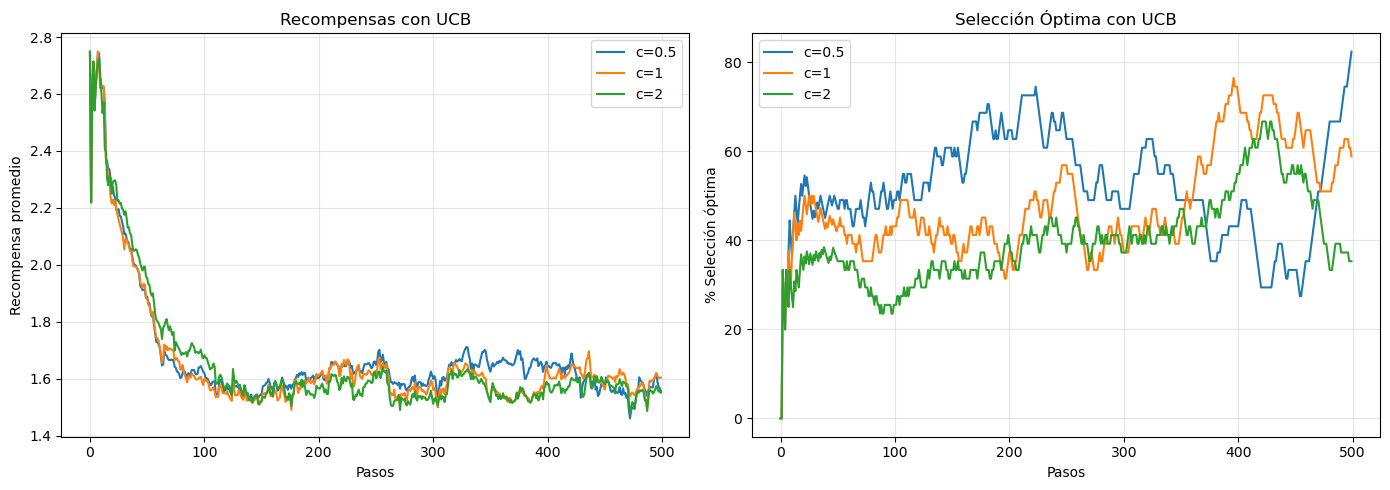

In [38]:
# Visualizar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for c in valores_c:
    promedio_movil = [np.mean(recompensas_ucb[c][max(0, i-50):i+1]) for i in range(len(recompensas_ucb[c]))]
    ax1.plot(promedio_movil, label=f'c={c}')

ax1.set_xlabel('Pasos')
ax1.set_ylabel('Recompensa promedio')
ax1.set_title('Recompensas con UCB')
ax1.legend()
ax1.grid(True, alpha=0.3)

for c in valores_c:
    promedio_optimas = [np.mean(acciones_optimas_ucb[c][max(0, i-50):i+1]) * 100 for i in range(len(acciones_optimas_ucb[c]))]
    ax2.plot(promedio_optimas, label=f'c={c}')

ax2.set_xlabel('Pasos')
ax2.set_ylabel('% Selección óptima')
ax2.set_title('Selección Óptima con UCB')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

UCB balancea exploración y explotación automáticamente. c=2 explora más, c=0.5 explota más rápido. El bonus de incertidumbre ayuda a descubrir zonas no visitadas.

## Método de Gradiente (Softmax)

In [39]:
# Función softmax
def softmax(H):
    exp_H = np.exp(H - np.max(H))
    return exp_H / np.sum(exp_H)

# Valores de α a probar
alphas_grad = [0.1, 0.5, 1.0]
recompensas_grad = {a: [] for a in alphas_grad}
acciones_optimas_grad = {a: [] for a in alphas_grad}

for alpha in alphas_grad:
    env = LaberintoEnv()
    k = len(env.zonas)
    H = np.zeros(k)
    
    recompensas_totales = []
    selecciones_optimas = []
    recompensa_promedio = 0
    
    for paso in range(500):
        # Calcular probabilidades con softmax
        probs = softmax(H)
        
        # Seleccionar acción según probabilidades
        accion = np.random.choice(k, p=probs)
        
        recompensa = env.step(accion)
        
        # Actualizar preferencias con gradiente
        recompensa_promedio += 0.1 * (recompensa - recompensa_promedio)
        for a in range(k):
            if a == accion:
                H[a] += alpha * (recompensa - recompensa_promedio) * (1 - probs[a])
            else:
                H[a] -= alpha * (recompensa - recompensa_promedio) * probs[a]
        
        recompensas_totales.append(recompensa)
        mejor_zona = env.get_mejor_zona()
        selecciones_optimas.append(1 if accion == mejor_zona else 0)
    
    recompensas_grad[alpha] = recompensas_totales
    acciones_optimas_grad[alpha] = selecciones_optimas

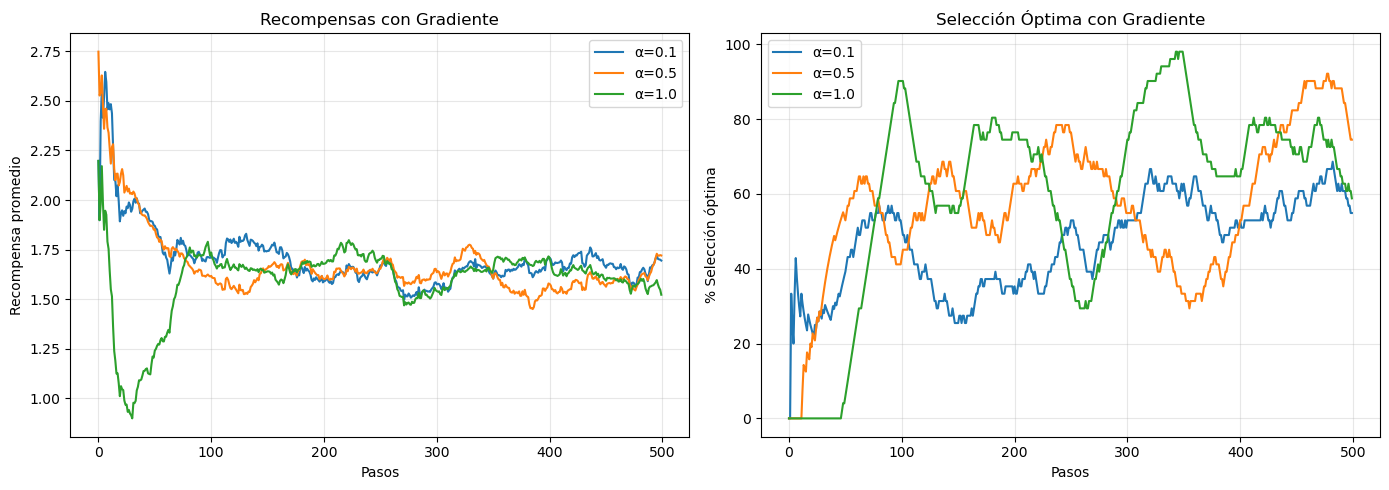

In [40]:
# Visualizar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for alpha in alphas_grad:
    promedio_movil = [np.mean(recompensas_grad[alpha][max(0, i-50):i+1]) for i in range(len(recompensas_grad[alpha]))]
    ax1.plot(promedio_movil, label=f'α={alpha}')

ax1.set_xlabel('Pasos')
ax1.set_ylabel('Recompensa promedio')
ax1.set_title('Recompensas con Gradiente')
ax1.legend()
ax1.grid(True, alpha=0.3)

for alpha in alphas_grad:
    promedio_optimas = [np.mean(acciones_optimas_grad[alpha][max(0, i-50):i+1]) * 100 for i in range(len(acciones_optimas_grad[alpha]))]
    ax2.plot(promedio_optimas, label=f'α={alpha}')

ax2.set_xlabel('Pasos')
ax2.set_ylabel('% Selección óptima')
ax2.set_title('Selección Óptima con Gradiente')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

El método de gradiente ajusta probabilidades suavemente. α alto converge rápido pero puede sobreajustarse. α bajo es más estable ante cambios del entorno.

## Comparación Final

Todos los métodos logran adaptarse al laberinto dinámico. ε-greedy es simple y efectivo. UCB balancea mejor exploración. Valores optimistas fuerzan exploración temprana. El método de gradiente es más suave pero más lento. La elección depende de qué tan cambiante sea el entorno.